In [ ]:
# Trajectory sampler
# ================================
# This section performs sampling of the original descriptors matrix or reduced ones from dim_red.ipynb to generate an initial dataset


## Package importation

In [3]:
import os, glob, json
import numpy as np
import pandas as pd
from sampler_utils import *
from dim_red_utils import load_pca_model
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.style as mplstyle
from plots_exports_utils import plot_sampling_pca, export_selected_structures, export_methods_bundle
# implementation from maml from reference: https://doi.org/10.1038/s41524-024-01227-4

from maml.sampling.direct import BirchClustering, DIRECTSampler, SelectKFromClusters


matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)
#matplotlib.use('Agg')  # Définir le backend en mode headless
mplstyle.use('fast') #The fast style set simplification and chunking parameters to reasonable settings to speed up plotting large amounts of data
plt.style.use("/Users/samuel/Desktop/postdoc_PhLAM/codes/mystyle.mplstyle")

Bad key legend.ncol in file /Users/samuel/Desktop/postdoc_PhLAM/codes/mystyle.mplstyle, line 37 ('legend.ncol: 1')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


## Data importation

In [2]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True 
if embedded_file:
    # Look for .npy file in embedding/ directory
    npy_files = glob.glob("embedding/*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/ directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")

    X = load_reduced(npy_file)  # or use np.load directly
    print("Loaded embedding with shape:", X.shape)

    pca_model_file = glob.glob("embedding/*.json") 
    if not pca_model_file:
        raise FileNotFoundError("No PCA model .json file found in embedding/ directory")
    if len(pca_model_file) > 1:
        raise RuntimeError(f"Multiple PCA model files found: {pca_model_file}")
    pca_model_file = pca_model_file[0]
    print(f"Using PCA model: {pca_model_file}")
    pca_model = load_pca_model(pca_model_file)
    
else: 
    # Look for .npy file in current directory
    npy_files = glob.glob("./*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")

# Find provenance parquet file
parquet_files = glob.glob("desc/*.parquet")
if not parquet_files:
    raise FileNotFoundError("No provenance .parquet file found in current directory")
if len(parquet_files) > 1:
    raise RuntimeError(f"Multiple parquet files found: {parquet_files}")
parquet_file = parquet_files[0]
print(f"Using provenance file: {parquet_file}")
meta = pd.read_parquet(parquet_file)

# Match corresponding JSON file with same timestamp
json_file = glob.glob("desc/*.json")
if not json_file:
    raise FileNotFoundError(f"No filemap JSON found")
if len(json_file) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_file}")
json_file = json_file[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

# specify the directory where sampling results are saved
path_to_results = "./selected" # Change if you want to save results elsewhere
os.makedirs(path_to_results, exist_ok=True)

#Check for NaNs

print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

# 1) whiten (float64 for stability)
X = np.asarray(X, dtype=np.float64, order="C")
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-12
Xw = (X - mu) / sd

print("Xw dtype/shape:", Xw.dtype, Xw.shape)
print("has_nan:", np.isnan(Xw).any(), "has_inf:", np.isinf(Xw).any(),
      "abs max:", np.nanmax(np.abs(Xw)))

Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (72720508, 4)
Using PCA model: embedding/pca_model.json
Using provenance file: desc/SOAP_N-O-C_provenance_20250925-115459.parquet
Using filemap: desc/SOAP_N-O-C_filemap_20250925-115459.json
X dtype/shape: float64 (72720508, 4)
has_nan: False has_inf: False abs max: 39.04179389712457
Xw dtype/shape: float64 (72720508, 4)
has_nan: False has_inf: False abs max: 18.216126522642124


## FPS sampling

In [ ]:
# # pick a sampler
# #  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
# method="fps"
# idx_atoms = sample(X, method=method, k=50000, seed=0, progress=True)

# # lift to structures
# chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")#choose="top", top_k=200)

# # save
# np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
# chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
#     X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
# )
# print("Mean coverage:", mean_cov)
# print("Per-PC bins used:", bins_used[:8])
# print("Per-PC coverage:", per_pc)

# plot_sampling_pca(X, idx_atoms, method="fps", per_pc=per_pc, npy_file=npy_file)

# # One method

# # Load sampled structures from CSV (not .npy)
# save_files_fps = True
# if save_files_fps:
#     paths = export_selected_structures(chosen_structs, method_name="FPS", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto")
#     print(paths)

Using Farthest-Point Sampling (FPS) ...


FPS:   0%|          | 1/49999 [00:06<88:39:23,  6.38s/it]


KeyboardInterrupt: 

### OPTION 1 - SAMPLE X, check COVERAGE - if not reached, perform new sampling with augmented number of points 

Using seeded batches auto-sampling strategy
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [01:09<00:00,  1.42it/s]


[fps-seeded] k=100 mean_cov=0.223
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [01:14<00:00,  1.34it/s]


[fps-seeded] +100 → k=200 mean_cov=0.366
Using Farthest-Point Sampling (FPS) ...


...

[fps-seeded] +100 → k=8,000 mean_cov=0.990
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [59:27<00:00, 36.03s/it]   


[fps-seeded] +100 → k=8,100 mean_cov=0.991
[fps] seeded auto-stop at k=8,100 with mean_cov=0.991
Per-PC bins used: [346, 475, 480, 251]
Per-PC coverage: [0.9940652818991098, 0.9852320675105485, 0.9851063829787234, 1.0]
Selected 6671 unique structures.


Assembling: 100%|██████████| 6671/6671 [00:00<00:00, 76996.66it/s]


{'traj': './selected/FPS_selected.traj', 'xyz': './selected/FPS_selected.xyz'}


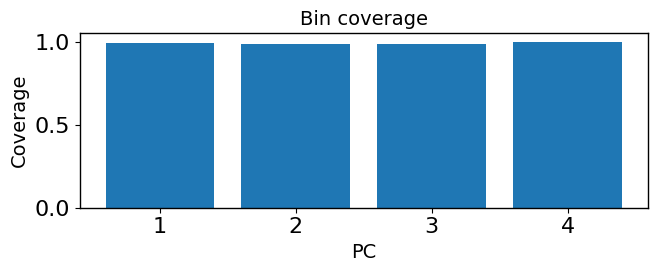

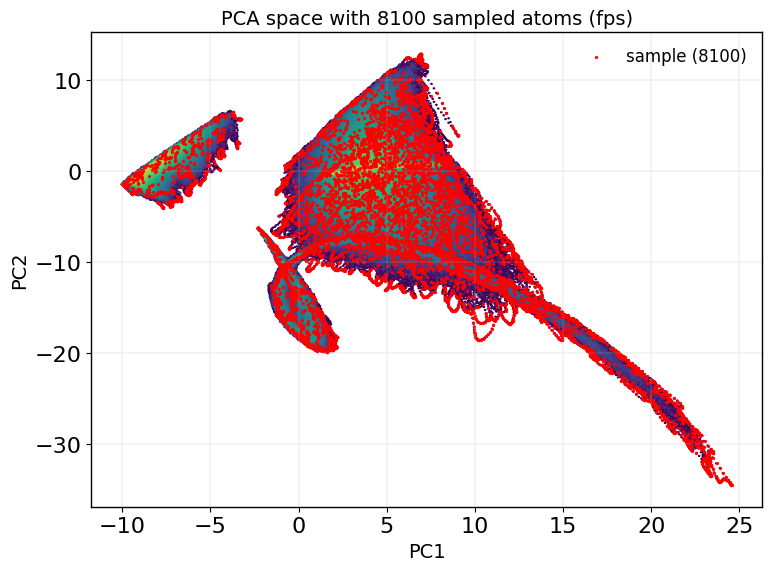

In [5]:
# --- config ---
method = "fps"                  # "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
auto_sampling = True            # True -> stop at target coverage, False -> fixed k
auto_strategy = "seeded"        # "resample" (sample_to_coverage) or "seeded" (seeded batches)
fixed_k = 50_000                # used if auto_sampling == False
seed = 0
progress = True

# auto params (both modes) 

target_mean_cov = 0.99
coverage_mode = "width"
target_width = 0.10
min_bins = 20
max_bins = 10_000

# resample-mode params
# In this case, a sample is performed. The PCA coverage is computed after sampling.
# if the coverage in not reached, a new sampling is performed with an augmented set of points

k_start = 100
k_max = 200_000
growth = 1.25                   # set None and use check_every for additive growth
check_every = None              # e.g., 5_000 for additive steps

# seeded-batches-mode params
# In this case, the number of sampled points is increased progressively until the target coverage is reached
# at each step, additional data are sampled with a different random seed and added to the previous set
# then, coverage is checked at every batch

batch = 100                   # points added per round (seeded mode)
k_max_seeded = 200_000          # cap for seeded mode (can reuse k_max if you prefer)
cov_along_sampl = []

# --- sampling ---
if auto_sampling:
    if auto_strategy == "seeded":
        print("Using seeded batches auto-sampling strategy")
        idx_atoms, info = sample_to_coverage_seeded_batches(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, batch=batch, k_max=k_max_seeded, seed=seed, progress=progress,
            coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] seeded auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
        cov_along_sampl.append(mean_cov)
    else:  # "resample"
        print("Using resample auto-sampling strategy")
        idx_atoms, info = sample_to_coverage(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, k_max=k_max, growth=growth, check_every=check_every,
            seed=seed, coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins, progress=progress
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] resample auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
        cov_along_sampl.append(mean_cov)
else:
    print("Using fixed-k sampling strategy")
    idx_atoms = sample(X, method=method, k=fixed_k, seed=seed, progress=progress)
    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx_atoms, mode=coverage_mode, target_width=target_width,
        min_bins=min_bins, max_bins=max_bins
    )
    print(f"[{method}] fixed k={fixed_k:,} mean_cov={mean_cov:.3f}")
    cov_along_sampl.append(mean_cov)

print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc[:8])

# --- lift to structures ---
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")  # or choose="top", top_k=200

# --- save ---
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# --- plot ---
plot_sampling_pca(X, idx_atoms, method=method, per_pc=per_pc, npy_file=npy_file)

# --- optional export ---
save_files = True
if save_files:
    paths = export_selected_structures(
        chosen_structs, method_name=method.upper(), outdir=path_to_results,
        extra_formats=("xyz",), load_mode="auto"
    )
    print(paths)

## Random sampling

Using random sampling ...
Selected 48409 unique structures.
Mean coverage: 0.6113965150611926
Per-PC bins used: [346, 475, 480, 251]
Per-PC coverage: [0.6201780415430267, 0.6181434599156118, 0.4702127659574468, 0.7370517928286853]


Assembling: 100%|██████████| 48409/48409 [00:00<00:00, 76672.94it/s]


{'traj': './selected/Random_selected.traj', 'xyz': './selected/Random_selected.xyz'}
Mean coverage  sampled: 0.611
Mean coverage  lifted : 0.626


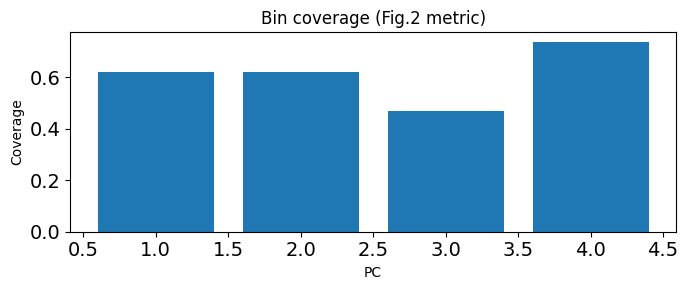

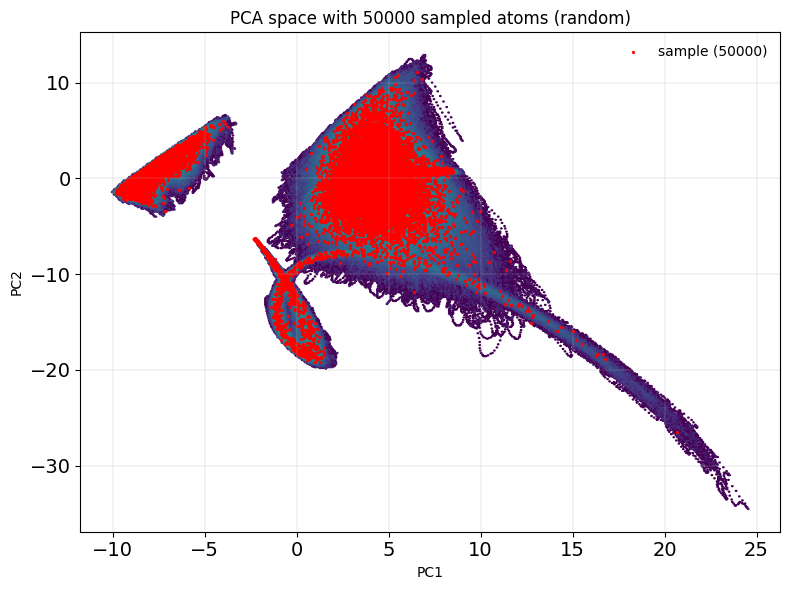

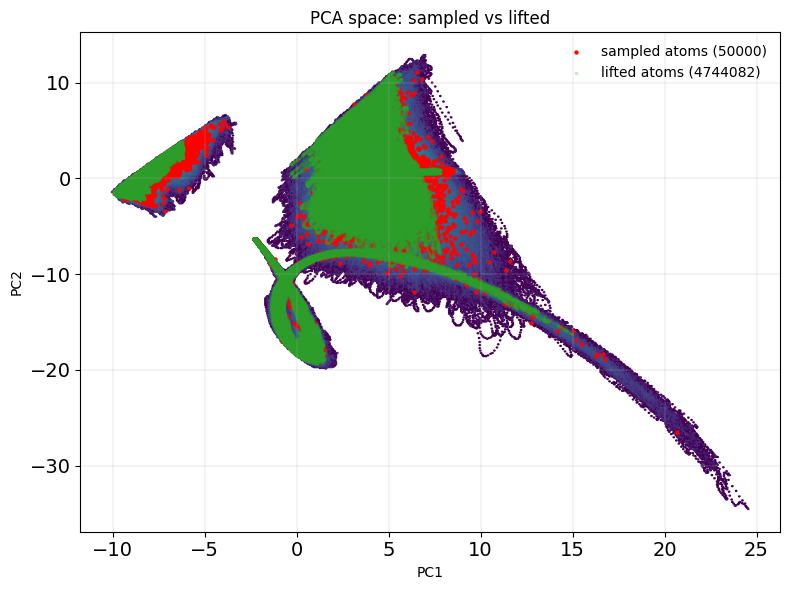

In [ ]:
# # pick a sampler
# #  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
# method="random"
# idx_atoms = sample(X, method=method, seed=42, k=50000, progress=True)
# #idx = sample(X, method="kpp", k=50000, progress=True)
# #idx = sample(X, method="kmedoids", k=10000, progress=True)
# #idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# # lift to structures
# chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all") #choose="top", top_k=200)
# #print(chosen_structs.head())

# # save
# np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
# chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
#     X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
# )
# print("Mean coverage:", mean_cov)
# print("Per-PC bins used:", bins_used[:8])
# print("Per-PC coverage:", per_pc)

# plot_sampling_pca(X, idx_atoms, method="random", per_pc=per_pc, npy_file=npy_file)

# # One method
# # export files — AUTO picks grouped if any file has >1 frame
# save_files_rdn = True
# if save_files_rdn:
#     paths = export_selected_structures(
#         chosen_structs,
#         method_name="Random",
#         outdir=path_to_results,
#         extra_formats=("xyz",),         # add "xdatcar" if needed
#         manifest=True,
#         write_traj=True,
#         load_mode="auto"                # or "grouped" to force one-shot reads
#     )
#     print(paths)


# # compute lifted indices
# idx_lifted = lifted_atom_indices_from_structs(meta, chosen_structs)

# # coverage: sampled vs lifted
# per_pc_s, mean_s, _ = pc_coverage_bins_auto(
#     X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
# )
# per_pc_L, mean_L, _ = pc_coverage_bins_auto(
#     X, idx_lifted, mode="width", target_width=0.1, min_bins=20, max_bins=10000
# )
# print(f"Mean coverage  sampled: {mean_s:.3f}")
# print(f"Mean coverage  lifted : {mean_L:.3f}")

# # PCA scatter: background + overlays (sampled in red, lifted in blue 'x')
# N = X.shape[0]
# fig, ax = plt.subplots(figsize=(8, 6))
# if N > 2_000_000:
#     ax.hexbin(X[:, 0], X[:, 1], gridsize=500, bins="log")
# else:
#     ax.scatter(X[:, 0], X[:, 1], s=1, alpha=0.05)

# ax.scatter(X[idx_atoms, 0],  X[idx_atoms, 1],  s=5,  alpha=0.9,  c="r",         marker="o", label=f"sampled atoms ({len(idx_atoms)})")
# ax.scatter(X[idx_lifted, 0], X[idx_lifted, 1], s=3,  alpha=0.25, c="tab:green", marker="x", label=f"lifted atoms ({len(idx_lifted)})")

# ax.set_xlabel("PC1", fontsize=14); ax.set_ylabel("PC2", fontsize=14)
# ax.set_title("PCA space: sampled vs lifted", fontsize=14)
# ax.grid(True, linewidth=0.2); ax.legend(frameon=False, loc="best", fontsize=12)
# plt.tight_layout(); plt.show()

In [8]:
# --- config ---
method = "random"               # "grid", "kpp", "kmedoids", "density_fps", "hdbscan", "random"
auto_sampling = True            # True -> stop at target coverage, False -> fixed k
auto_strategy = "seeded"        # "resample" or "seeded"
fixed_k = 50_000                # used if auto_sampling == False
seed = 42
progress = True

# coverage params
target_mean_cov = 0.95
coverage_mode = "width"
target_width = 0.10
min_bins = 20
max_bins = 10_000

# resample-mode params
k_start = 100
k_max = 200_000
growth = 1.25
check_every = None

# seeded-batches-mode params
batch = 100
k_max_seeded = 200_000

# --- sampling ---
if auto_sampling:
    if auto_strategy == "seeded":
        idx_atoms, info = sample_to_coverage_seeded_batches(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, batch=batch, k_max=k_max_seeded, seed=seed, progress=progress,
            coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] seeded auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
    else:  # "resample"
        idx_atoms, info = sample_to_coverage(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, k_max=k_max, growth=growth, check_every=check_every,
            seed=seed, coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins, progress=progress
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] resample auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
else:
    idx_atoms = sample(X, method=method, seed=seed, k=fixed_k, progress=progress)
    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx_atoms, mode=coverage_mode, target_width=target_width,
        min_bins=min_bins, max_bins=max_bins
    )
    print(f"[{method}] fixed k={fixed_k:,} mean_cov={mean_cov:.3f}")

print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc[:8])

# --- lift to structures ---
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")  # or choose="top", top_k=200

# --- save ---
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# --- plot (sampled) ---
plot_sampling_pca(X, idx_atoms, method=method, per_pc=per_pc, npy_file=npy_file)

# --- optional export ---
save_files_rdn = True
if save_files_rdn:
    paths = export_selected_structures(
        chosen_structs,
        method_name=method.upper(),
        outdir=path_to_results,
        extra_formats=("xyz",),
        manifest=True,
        write_traj=True,
        load_mode="auto"
    )
    print(paths)

# --- lifted indices and coverage comparison ---
idx_lifted = lifted_atom_indices_from_structs(meta, chosen_structs)

per_pc_s, mean_s, _ = pc_coverage_bins_auto(
    X, idx_atoms, mode=coverage_mode, target_width=target_width, min_bins=min_bins, max_bins=max_bins
)
per_pc_L, mean_L, _ = pc_coverage_bins_auto(
    X, idx_lifted, mode=coverage_mode, target_width=target_width, min_bins=min_bins, max_bins=max_bins
)
print(f"Mean coverage  sampled: {mean_s:.3f}")
print(f"Mean coverage  lifted : {mean_L:.3f}")

# --- PCA scatter: background + overlays ---
N = X.shape[0]
fig, ax = plt.subplots(figsize=(8, 6))
if N > 2_000_000:
    ax.hexbin(X[:, 0], X[:, 1], gridsize=500, bins="log")
else:
    ax.scatter(X[:, 0], X[:, 1], s=1, alpha=0.05)

ax.scatter(X[idx_atoms, 0],  X[idx_atoms, 1],  s=5,  alpha=0.9,  c="r",           marker="o", label=f"sampled atoms ({len(idx_atoms)})")
ax.scatter(X[idx_lifted, 0], X[idx_lifted, 1], s=3,  alpha=0.25, c="tab:green",   marker="x", label=f"lifted atoms ({len(idx_lifted)})")

ax.set_xlabel("PC1", fontsize=14); ax.set_ylabel("PC2", fontsize=14)
ax.set_title("PCA space: sampled vs lifted", fontsize=14)
ax.grid(True, linewidth=0.2); ax.legend(frameon=False, loc="best", fontsize=12)
plt.tight_layout(); plt.show()

Using random sampling ...
[random-seeded] k=100 mean_cov=0.138
Using random sampling ...
[random-seeded] +100 → k=200 mean_cov=0.183
Using random sampling ...
[random-seeded] +100 → k=300 mean_cov=0.205
Using random sampling ...
[random-seeded] +100 → k=400 mean_cov=0.225
Using random sampling ...
[random-seeded] +100 → k=500 mean_cov=0.242
Using random sampling ...
[random-seeded] +100 → k=600 mean_cov=0.252
Using random sampling ...
[random-seeded] +100 → k=700 mean_cov=0.259
Using random sampling ...
[random-seeded] +100 → k=800 mean_cov=0.269
Using random sampling ...
[random-seeded] +100 → k=900 mean_cov=0.277
Using random sampling ...
[random-seeded] +100 → k=1,000 mean_cov=0.284
Using random sampling ...
[random-seeded] +100 → k=1,100 mean_cov=0.292
Using random sampling ...
[random-seeded] +100 → k=1,200 mean_cov=0.301
Using random sampling ...
[random-seeded] +100 → k=1,300 mean_cov=0.312
Using random sampling ...
[random-seeded] +100 → k=1,400 mean_cov=0.315
Using random samp

KeyboardInterrupt: 

## BIRCH - my implementation (CURRENTLY CRASHING !!)

In [ ]:
my_implementation_of_birch = False
if my_implementation_of_birch:

    # inputs: PCA embedding Z (all rows), explained_variance EV (from your saved JSON)
    from sampler_utils import direct_birch_sample, pc_bin_coverage

    idx, info = direct_birch_sample(
        #Z_pca=first_two_PC, ev=ev_two_PC,
        Z_pca=X[:1000000], ev=pca_model.explained_variance_,
        n_clusters=100,          # or None → CF subclusters
        threshold=0.15,
        branching_factor=50,
        k_per_cluster=10,
        progress=True
    )
    print(info)

    # lift to structures with your existing atoms_to_structures(...)
    chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

    # save
    method="birch"
    np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
    chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
    )
    print("Mean coverage:", mean_cov)
    print("Per-PC bins used:", bins_used[:8])
    print("Per-PC coverage:", per_pc)

    plot_sampling_pca(X, idx, method="birch", per_pc=per_pc, npy_file=npy_file)

    # One method
    save_files_birch = False
    if save_files_birch:
        paths = export_selected_structures(chosen_structs, method_name="Birch", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
        #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
        print(paths)

Using DIRECT-style BIRCH sampling ...
from reference: https://doi.org/10.1038/s41524-024-01227-4


: 

In [5]:
DIRECT_sampler = DIRECTSampler(
    structure_encoder=None,
    pca=None,
    scaler=None,
    weighting_PCs=True,
    clustering=BirchClustering(n=10000, threshold_init=0.15), select_k_from_clusters=SelectKFromClusters(k=5)
)

DIRECT_selection = DIRECT_sampler.fit_transform(X)

idx = DIRECT_selection["selected_indexes"]

chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

# save
method="birch"
#np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
#chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx, method="birch", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_birch = False
if save_files_birch:
    paths = export_selected_structures(chosen_structs, method_name="Birch", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)

: 

## KPP 

In [ ]:
# # pick a sampler
# #  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
# method="kpp"
# idx = sample(X, method="kpp", k=15000, progress=True)

# # lift to structures
# chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all") #choose="top", top_k=200)
# #print(chosen_structs.head())

# # save
# np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
# chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
#     X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
# )
# print("Mean coverage:", mean_cov)
# print("Per-PC bins used:", bins_used[:8])
# print("Per-PC coverage:", per_pc)

# plot_sampling_pca(X, idx, method="kpp", per_pc=per_pc, npy_file=npy_file)

# # One method
# save_files_kpp = False
# if save_files_kpp:
#     paths = export_selected_structures(chosen_structs, method_name="KPP", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
#     #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
#     print(paths)

In [9]:
# --- config ---
method = "kpp"                 # "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
auto_sampling = True           # True: stop at target coverage; False: fixed k
auto_strategy = "seeded"       # "resample" (sample_to_coverage) or "seeded" (seeded batches)
fixed_k = 15_000               # used if auto_sampling == False
seed = 0
progress = True

# coverage params
target_mean_cov = 0.95
coverage_mode = "width"
target_width = 0.10
min_bins = 20
max_bins = 10_000

# resample-mode params
k_start = 100
k_max = 100_000
growth = 1.25                  # or set None and use check_every
check_every = None             # e.g., 2_500

# seeded-batches-mode params
batch = 100
k_max_seeded = 100_000

# --- sampling ---
if auto_sampling:
    if auto_strategy == "seeded":
        idx, info = sample_to_coverage_seeded_batches(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, batch=batch, k_max=k_max_seeded, seed=seed, progress=progress,
            coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] seeded auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
    else:  # "resample"
        idx, info = sample_to_coverage(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, k_max=k_max, growth=growth, check_every=check_every,
            seed=seed, coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins, progress=progress
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] resample auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
else:
    idx = sample(X, method=method, k=fixed_k, seed=seed, progress=progress)
    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx, mode=coverage_mode, target_width=target_width,
        min_bins=min_bins, max_bins=max_bins
    )
    print(f"[{method}] fixed k={fixed_k:,} mean_cov={mean_cov:.3f}")

print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc[:8])

# --- lift to structures ---
chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")  # or choose="top", top_k=200)

# --- save ---
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

# --- plot ---
plot_sampling_pca(X, idx, method=method, per_pc=per_pc, npy_file=npy_file)

# --- optional export ---
save_files = False
if save_files:
    paths = export_selected_structures(
        chosen_structs, method_name=method.upper(),
        outdir=path_to_results, extra_formats=("xyz",), load_mode="auto"
    )
    print(paths)

Using k-means++ sampling ...


k-means++: 100%|██████████| 99/99 [01:49<00:00,  1.10s/it]


[kpp-seeded] k=100 mean_cov=0.182
Using k-means++ sampling ...


k-means++: 100%|██████████| 99/99 [01:57<00:00,  1.19s/it]


[kpp-seeded] +100 → k=200 mean_cov=0.264
Using k-means++ sampling ...


...

[kpp-seeded] +100 → k=11,800 mean_cov=0.871
Using k-means++ sampling ...


k-means++: 100%|██████████| 99/99 [01:53<00:00,  1.14s/it]


[kpp-seeded] +100 → k=11,900 mean_cov=0.871
Using k-means++ sampling ...


k-means++:   1%|          | 1/99 [00:03<05:21,  3.29s/it]


KeyboardInterrupt: 